OTIMIZANDO f(x) = x * sin(3x)
Geração   0: Melhor f(x) = 6.7689 (x = 6.7843)
Geração  10: Melhor f(x) = 7.8038 (x = 8.7451)
Geração  20: Melhor f(x) = 7.8038 (x = 8.7451)
Geração  30: Melhor f(x) = 7.8038 (x = 8.7451)
Geração  40: Melhor f(x) = 7.8038 (x = 8.7451)


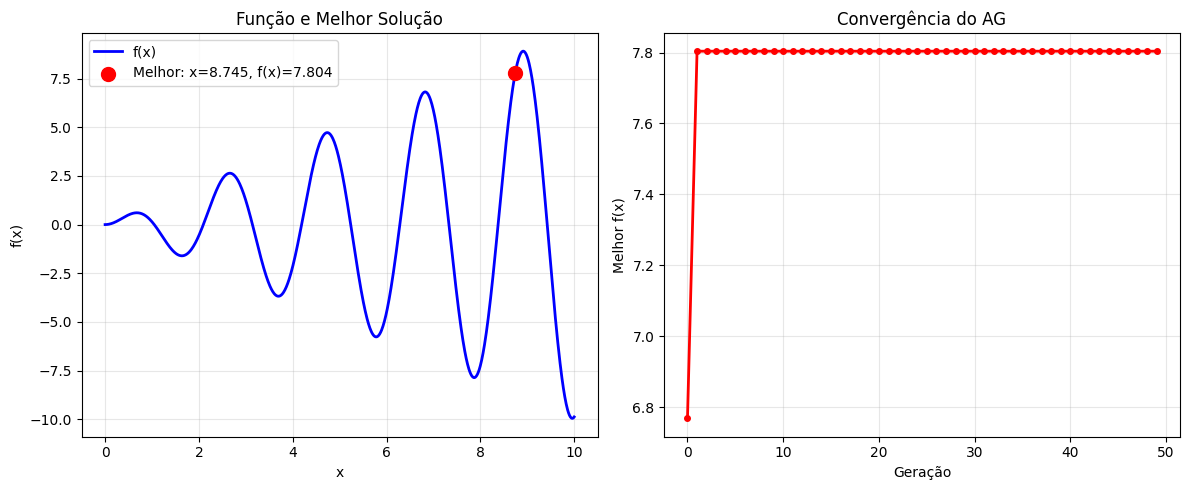


 MELHOR SOLUÇÃO: x = 8.7451, f(x) = 7.8038


In [39]:
#ATIVIDADE 3: Complete o Algoritmo Genético
#Problema: Encontrar x ∈ [0, 10] que maximiza f(x) = x * sin(3x)

import numpy as np
import matplotlib.pyplot as plt
import random

# ==================== CONFIGURAÇÕES ====================
BITS = 8              # 8 bits → valores de 0 a 255
POP_SIZE = 20
GERACOES = 50
TAXA_CROSS = 0.8
TAXA_MUT = 0.05

# Intervalo de x
X_MIN = 0
X_MAX = 10

# ==================== FUNÇÃO OBJETIVO ====================
def funcao_objetivo(x):
    """f(x) = x * sin(3*x)"""
    return x * np.sin(3 * x)

# ==================== FUNÇÕES A COMPLETAR ====================

# TODO 1: Converter bits para x real
def bits_para_x(bits):
    """
    Converte lista de 8 bits para valor real no intervalo [X_MIN, X_MAX].
    Dica: primeiro converta para decimal, depois normalize.
    """
    decimal_val = 0
    for i, bit in enumerate(reversed(bits)):
        decimal_val += bit * (2 ** i)

    # Normaliza o valor decimal para o intervalo [X_MIN, X_MAX]
    # O valor máximo que 8 bits podem representar é 2^8 - 1 = 255
    x = X_MIN + (decimal_val / (2**BITS - 1)) * (X_MAX - X_MIN)
    return x

# TODO 2: Calcular fitness (nota) de um indivíduo
def fitness(individuo):
    """
    Calcula o fitness de um indivíduo.
    Lembre-se: Queremos MAXIMIZAR f(x).
    """
    x = bits_para_x(individuo)
    return funcao_objetivo(x)

# TODO 3: Mutação bit-flip
def mutacao(individuo):
    """
    Aplica mutação bit-flip.
    Cada bit tem TAXA_MUT de chance de ser invertido.
    """
    # Cria uma cópia para não modificar o indivíduo original diretamente
    # antes de decidir se a mutação realmente ocorrerá.
    mutated_individuo = individuo.copy()
    for i in range(len(mutated_individuo)):
        if random.random() < TAXA_MUT:
            mutated_individuo[i] = 1 - mutated_individuo[i] # Inverte o bit (0 vira 1, 1 vira 0)
    return mutated_individuo

# ==================== CÓDIGO PRONTO (NÃO MEXER) ====================

def criar_individuo():
    return [random.randint(0, 1) for _ in range(BITS)]

def criar_populacao():
    return [criar_individuo() for _ in range(POP_SIZE)]

def selecao_roleta(pop, fitnesses):
    total = sum(fitnesses)
    # Adiciona uma verificação para garantir que o total não seja zero,
    # o que pode acontecer se todos os fitness forem negativos ou zero (e o problema for de maximização)
    if total <= 0:
        # Se o total for zero ou negativo, todos os indivíduos têm a mesma chance
        # ou o problema não tem solução positiva. Escolhe aleatoriamente ou o melhor se houver.
        if any(f > 0 for f in fitnesses): # Se houver algum fitness positivo, seleciona o melhor.
            return pop[np.argmax(fitnesses)].copy()
        return random.choice(pop).copy() # Caso contrário, escolha um aleatoriamente.

    pick = random.uniform(0, total)
    acumulado = 0
    for i, ind in enumerate(pop):
        acumulado += fitnesses[i]
        if acumulado >= pick:
            return ind.copy()
    return pop[-1].copy() # Fallback, should not be reached if total > 0

def crossover(pai1, pai2):
    if random.random() > TAXA_CROSS:
        return pai1.copy(), pai2.copy()
    ponto = random.randint(1, BITS - 1)
    filho1 = pai1[:ponto] + pai2[ponto:]
    filho2 = pai2[:ponto] + pai1[ponto:]
    return filho1, filho2

def executar_ag():
    pop = criar_populacao()
    historico = []

    for gen in range(GERACOES):
        # Avaliar
        fitnesses = [fitness(ind) for ind in pop]

        # Adiciona uma pequena perturbação a fitnesses para evitar problemas com valores repetidos
        # ou todos os fitnesses sendo idênticos (o que pode acontecer se a função objetivo for plana em um segmento)
        # ou se todos forem zero/negativos e precisamos de um máximo.
        adjusted_fitnesses = [f if f > 0 else 0.001 for f in fitnesses] # Garante valores positivos para seleção roleta

        melhor_fit = max(fitnesses)
        melhor_ind = pop[fitnesses.index(melhor_fit)]
        melhor_x = bits_para_x(melhor_ind)
        historico.append((melhor_x, melhor_fit))

        if gen % 10 == 0:
            print(f"Geração {gen:3d}: Melhor f(x) = {melhor_fit:.4f} (x = {melhor_x:.4f})")

        # Elitismo (mantém os 2 melhores indivíduos para a próxima geração)
        sorted_idx = np.argsort(fitnesses)[::-1] # Índices dos indivíduos ordenados do melhor para o pior
        nova_pop = [pop[i].copy() for i in sorted_idx[:2]] # Pega os 2 melhores

        # Criar filhos até que a população atinja o tamanho POP_SIZE
        while len(nova_pop) < POP_SIZE:
            pai1 = selecao_roleta(pop, adjusted_fitnesses)
            pai2 = selecao_roleta(pop, adjusted_fitnesses)
            filho1, filho2 = crossover(pai1, pai2)
            nova_pop.append(mutacao(filho1))
            if len(nova_pop) < POP_SIZE:
                nova_pop.append(mutacao(filho2))

        pop = nova_pop # A nova população substitui a antiga

    return historico

# ==================== EXECUTAR ====================
print("=" * 50)
print("OTIMIZANDO f(x) = x * sin(3x)")
print("=" * 50)

historico = executar_ag()

# Visualizar
x_plot = np.linspace(X_MIN, X_MAX, 1000)
y_plot = funcao_objetivo(x_plot)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(x_plot, y_plot, 'b-', linewidth=2, label='f(x)')
# Garante que o histórico não está vazio antes de tentar encontrar o máximo
if historico:
    melhor_x_final, melhor_fit_final = max(historico, key=lambda x: x[1])
    plt.scatter(melhor_x_final, melhor_fit_final, color='red', s=100, zorder=5, label=f'Melhor: x={melhor_x_final:.3f}, f(x)={melhor_fit_final:.3f}')
else:
    melhor_x_final, melhor_fit_final = float('nan'), float('nan') # Se o histórico estiver vazio

plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Função e Melhor Solução')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
x_hist = [h[0] for h in historico]
y_hist = [h[1] for h in historico]
plt.plot(range(GERACOES), y_hist, 'r-o', linewidth=2, markersize=4)
plt.xlabel('Geração')
plt.ylabel('Melhor f(x)')
plt.title('Convergência do AG')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n MELHOR SOLUÇÃO: x = {melhor_x_final:.4f}, f(x) = {melhor_fit_final:.4f}")